# Práctica 5: Linear Models & Correlation


### Modelos Lineales
Un modelo de regresión lineal simple busca encontrar la "línea de mejor ajuste" que describa la relación entre una variable independiente ($X$) y una variable dependiente ($Y$). La fórmula se expresa como:
$$Y = \beta_0 + \beta_1X + \epsilon$$
Donde:
*   $\beta_0$ es la intersección (ordenada al origen).
*   $\beta_1$ es la pendiente de la línea (cuánto cambia $Y$ por cada unidad de $X$).
*   $\epsilon$ es el error.
El ajuste del modelo se evalúa comúnmente con la métrica **$R^2$ (R-cuadrado)**, que indica la proporción de la varianza en la variable dependiente que es predecible a partir de la variable independiente (es decir, qué tan bien se ajustan los datos a la línea).

### Análisis 
La **correlación** mide la fuerza y la dirección (positiva o negativa) de una relación lineal entre dos variables, oscilando entre -1 y 1. 
Es crucial destacar la regla de oro en estadística: **Correlación no implica causalidad**. Si descubrimos que la variable de "Medicamentos recetados" sube al mismo tiempo que la variable de "Terapia recibida", esto indica una asociación matemática fuerte, pero *no prueba* que tomar medicamentos cause que la gente vaya a terapia (podría haber un factor externo, como las políticas de salud pública del estado, que impulse ambas).


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/Mental_Health_Clean_Final.csv")

# Filtramos los datos a nivel de 'Estado' 
df_states = df[df['Group'] == 'By State'].copy()

# queremos comparar dos indicadores específicos dentro del mismo Estado y Periodo de Tiempo
# X = Took Prescription Medication for Mental Health
# Y = Received Counseling or Therapy
df_pivot = df_states.pivot_table(
    index=['State', 'Time Period'], 
    columns='Indicator', 
    values='Value'
).dropna()

# renombramos las columnas 
df_pivot = df_pivot.rename(columns={
    "Took Prescription Medication for Mental Health, Last 4 Weeks": "Medication",
    "Received Counseling or Therapy, Last 4 Weeks": "Therapy"
})

# datos preparados
display(df_pivot[['Medication', 'Therapy']].head())

Indicator            Medication  Therapy
State   Time Period                     
Alabama 13                 22.3      8.5
        14                 21.0      6.9
        15                 25.9      7.5
        16                 26.7      7.6
        17                 21.6      6.4

## Análisis de Correlación

Calcularemos la matriz de correlación para entender la fuerza y dirección de la relación entre el uso de medicamentos psiquiátricos y el uso de terapia en los diferentes estados.


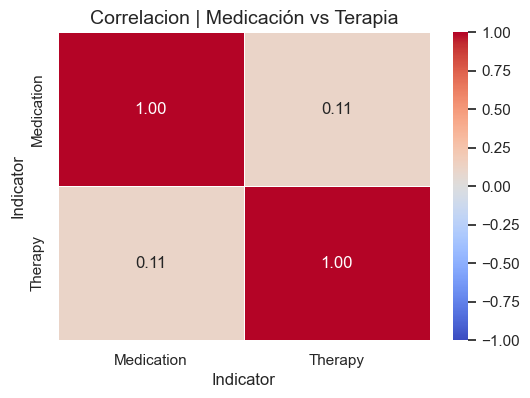

Coeficiente de correlación de Pearson (r): 0.1107
La correlación es débil o nula.


In [10]:
correlacion = df_pivot[['Medication', 'Therapy']].corr()

# correlación usando un Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Correlacion | Medicación vs Terapia", fontsize=14)
plt.show()

corr_value = correlacion.loc['Medication', 'Therapy']

print(f"Coeficiente de correlación de Pearson (r): {corr_value:.4f}")
if corr_value > 0.7:
    print("Existe una fuerte correlación POSITIVA entre ambas variables.")
elif corr_value > 0.3:
    print("Existe una correlación POSITIVA MODERADA.")
else:
    print("La correlación es débil o nula.")

## Regresión Lineal 

Regresión Lineal. 
*   **Variable Independiente ($X$):** Porcentaje de la población que tomó medicación (`Medication`).
*   **Variable Dependiente ($Y$):** Porcentaje de la población que recibió terapia (`Therapy`).

objetivo del modelo será: *Predecir el porcentaje de población que buscará terapia en un estado dado, basándonos en el nivel de prescripción de medicamentos reportado.*


--- RESULTADOS ---
Ecuación lineal: Y = 0.0763 * X + (8.5303)
R2 Score: 0.0123


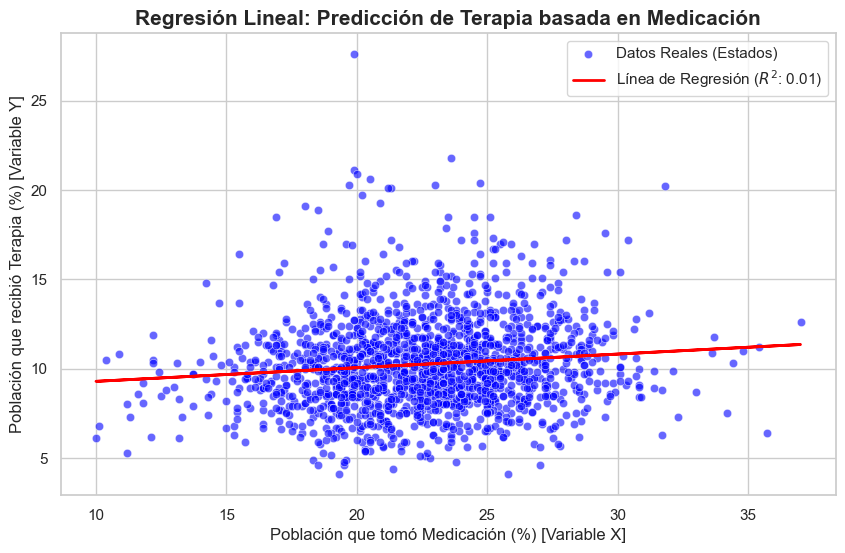

In [11]:
X = df_pivot[['Medication']]
y = df_pivot['Therapy']

model = LinearRegression()

# ajuste (entrenamiento)
model.fit(X, y)

# predicciones
y_pred = model.predict(X)

# ecuación (y = mx + b)
beta_1 = model.coef_[0]      # pendiente # primer valor del array
beta_0 = model.intercept_    # intersección
r2 = r2_score(y, y_pred)     # R-squared Score

print("--- RESULTADOS ---")
print(f"Ecuación lineal: Y = {beta_1:.4f} * X + ({beta_0:.4f})")
print(f"R2 Score: {r2:.4f}")

plt.figure(figsize=(10, 6))

sns.scatterplot(x=X['Medication'], y=y, color="blue", alpha=0.6, label="Datos Reales (Estados)")

# línea de regresión
plt.plot(X['Medication'], y_pred, color="red", linewidth=2, label=f"Línea de Regresión ($R^2$: {r2:.2f})")

plt.title("Regresión Lineal: Predicción de Terapia basada en Medicación", fontsize=15, fontweight='bold')
plt.xlabel("Población que tomó Medicación (%) [Variable X]", fontsize=12)
plt.ylabel("Población que recibió Terapia (%) [Variable Y]", fontsize=12)
plt.legend()
plt.show()

## Interpretación y Resultados 

1.  **Fuerza de la Correlación y Causalidad:** 
    *   Los resultados del Heatmap y del modelo muestran una correlación lineal sumamente débil. La tasa poblacional de personas que consumen medicamentos psiquiátricos **no** aumenta ni disminuye de manera proporcional con la tasa de personas que asisten a terapia.
    *   Esto demuestra que ambas variables son afectadas por factores externos independientes. Por ejemplo, es posible que el acceso a medicamentos haya sido más fácil en ciertos estados, mientras que el acceso a terapia estuvo limitado por la falta de psicólogos o barreras económicas durante la pandemia.
2.  **Modelo Lineal y R2 Score:**
    * El **Score $R^2$ obtenido es de 0.0123**. Esto significa que nuestro modelo lineal solo es capaz de explicar el **1.23%** de la varianza. 
    * Un modelo de regresión lineal simple no es el algoritmo adecuado para predecir el comportamiento cruzado de estos indicadores cuando se mezclan múltiples periodos temporales (`Time Period`) y diferentes regiones geográficas (`State`). La relación entre ambas variables no es lineal.